# Unidade IV — Mineração de Padrões

## Avaliação de regras e padrões sequenciais

**Carga estimada:** 2 horas  
**Pré-requisitos:** suporte, confiança, *lift* e regras de associação.

> **Pergunta norteadora:** quando um padrão frequente merece atenção e como incorporar a ordem dos eventos?


## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir regra frequente, forte, interessante e acionável;
- interpretar *lift*, alavancagem e convicção;
- reconhecer redundância, taxa-base e associação sem causalidade;
- representar sequências e calcular suporte de subsequências.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid", context="notebook")


## Forte não significa útil

Uma regra pode superar suporte e confiança mínimos e ainda ser óbvia, redundante, instável ou impossível de usar. Confiança alta pode refletir apenas um consequente comum. Medidas complementares incluem

$$\operatorname{leverage}(X\rightarrow Y)=\operatorname{sup}(X\cup Y)-\operatorname{sup}(X)\operatorname{sup}(Y),$$

$$\operatorname{conviction}(X\rightarrow Y)=\frac{1-\operatorname{sup}(Y)}{1-\operatorname{conf}(X\rightarrow Y)}.$$

Alavancagem mede diferença absoluta diante da independência. Convicção compara falhas esperadas e observadas e tende ao infinito quando a confiança é 1. Nenhuma medida prova causalidade ou utilidade.


In [2]:
transacoes = [
    ["arroz", "feijao", "oleo"], ["arroz", "feijao"],
    ["arroz", "leite"], ["pao", "leite", "manteiga"],
    ["pao", "leite"], ["arroz", "feijao", "oleo"],
    ["pao", "cafe"], ["arroz", "feijao", "leite"],
    ["pao", "leite", "manteiga"], ["arroz", "feijao"],
    ["cafe", "leite"], ["arroz", "feijao", "oleo", "leite"],
]
te = TransactionEncoder()
cestas = pd.DataFrame(te.fit(transacoes).transform(transacoes), columns=te.columns_)
itemsets = apriori(cestas, min_support=0.15, use_colnames=True)
regras = association_rules(itemsets, metric="confidence", min_threshold=0.60)
colunas = ["antecedents", "consequents", "support", "confidence", "lift", "leverage", "conviction"]
regras[colunas].sort_values(["lift", "support"], ascending=False).head(12).round(3)


,antecedents,consequents,support,confidence,lift,leverage,conviction
13,"(pao, leite)",(manteiga),0.167,0.667,4.000,0.125,2.5
15,(manteiga),"(pao, leite)",0.167,1.000,4.000,0.125,inf
6,(manteiga),(pao),0.167,1.000,3.000,0.111,inf
14,"(manteiga, leite)",(pao),0.167,1.000,3.000,0.111,inf
3,(oleo),(feijao),0.250,1.000,2.000,0.125,inf
9,"(oleo, arroz)",(feijao),0.250,1.000,2.000,0.125,inf
11,(oleo),"(arroz, feijao)",0.250,1.000,2.000,0.125,inf
0,(arroz),(feijao),0.500,0.857,1.714,0.208,3.5
1,(feijao),(arroz),0.500,1.000,1.714,0.208,inf
2,(oleo),(arroz),0.250,1.000,1.714,0.104,inf


## Avaliação responsável

Uma análise defensável combina força descritiva, contagens, estabilidade em outros períodos, novidade, redundância, acionabilidade e riscos. Promoções, disponibilidade, sazonalidade e segmentação podem explicar associações. Testar muitas regras aumenta coincidências; um período de confirmação e busca controlada reduzem conclusões oportunistas. Efeito de intervenção exige desenho causal apropriado.


## De itemsets a padrões sequenciais

Uma transação trata itens como conjunto; uma sequência preserva a ordem. O padrão $\langle a,c\rangle$ ocorre em $\langle a,b,c\rangle$ porque seus eventos aparecem na ordem, mesmo sem adjacência. Suporte sequencial é a proporção de sequências de entidades distintas que contêm o padrão ao menos uma vez. Repetições do padrão na mesma entidade não aumentam o numerador além de uma ocorrência.


In [3]:
jornadas = {
    "C1": ["visita", "busca", "produto", "compra"],
    "C2": ["visita", "produto", "compra"],
    "C3": ["visita", "busca", "produto", "abandono"],
    "C4": ["busca", "produto", "compra"],
    "C5": ["visita", "produto", "suporte"],
    "C6": ["visita", "busca", "produto", "compra"],
}
pd.DataFrame({
    "cliente": jornadas.keys(),
    "sequencia": [" → ".join(s) for s in jornadas.values()],
})


,cliente,sequencia
0,C1,visita → busca → produto → compra
1,C2,visita → produto → compra
2,C3,visita → busca → produto → abandono
3,C4,busca → produto → compra
4,C5,visita → produto → suporte
5,C6,visita → busca → produto → compra


In [4]:
def contem_subsequencia(sequencia: list[str], padrao: tuple[str, ...]) -> bool:
    """Verifica ocorrência ordenada, não necessariamente contígua."""
    posicao = 0
    for evento in sequencia:
        if posicao < len(padrao) and evento == padrao[posicao]:
            posicao += 1
    return posicao == len(padrao)


padroes = [
    ("visita", "produto"), ("busca", "compra"),
    ("produto", "compra"), ("visita", "busca", "compra"),
]
suportes_sequenciais = pd.Series({
    " → ".join(p): sum(
        contem_subsequencia(s, p) for s in jornadas.values()
    ) / len(jornadas)
    for p in padroes
}).sort_values(ascending=False)
suportes_sequenciais.round(3)


visita → produto           0.833
produto → compra           0.667
busca → compra             0.500
visita → busca → compra    0.333
dtype: float64

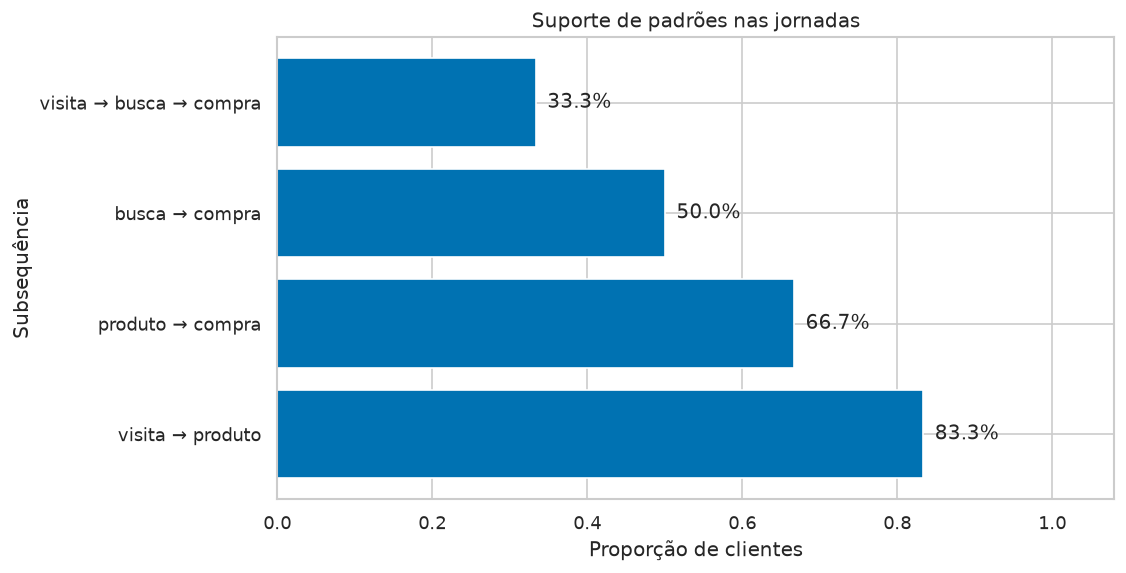

In [5]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
barras = ax.barh(
    suportes_sequenciais.index, suportes_sequenciais.values, color="#0072B2"
)
for barra in barras:
    ax.text(
        barra.get_width() + 0.015, barra.get_y() + barra.get_height() / 2,
        f"{barra.get_width():.1%}", va="center",
    )
ax.set(
    title="Suporte de padrões nas jornadas",
    xlabel="Proporção de clientes", ylabel="Subsequência", xlim=(0, 1.08),
)
plt.show()


`visita → produto` ocorre em cinco das seis jornadas; `produto → compra`, em quatro. Isso não implica que visualizar o produto cause compra: intenção prévia, seleção de visitantes e desenho do site podem explicar o padrão. Também seria preciso definir janela temporal, eventos simultâneos, lacunas máximas e mudanças do sistema.


> **U04-NB03-V01 — Verifique seu entendimento:** qual informação é perdida ao transformar uma jornada ordenada em uma cesta de eventos?

> **U04-NB03-E01 — Exercício:** acrescente duas jornadas, uma com eventos repetidos e outra com dois eventos no mesmo instante. Declare uma regra para ordenar ou agrupar empates, recalcule os suportes e explique o efeito.

> **U04-NB03-E02 — Atividade integradora:** escolha uma base transacional ou sequencial pequena; documente unidade, período e representação; minere padrões com dois limiares; selecione no máximo cinco resultados usando frequência, interesse, estabilidade e utilidade; e produza recomendação com contagens, limitações e ressalva causal.


## Síntese

- Regra forte por limiar não é automaticamente interessante ou acionável.
- Taxa-base, contagem, estabilidade e redundância complementam as métricas.
- Sequências preservam ordem e exigem definições temporais explícitas.
- Padrões observacionais sustentam hipóteses, não conclusões causais.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Caps. 4 e 5, seção 5.4.
- AGRAWAL, Rakesh; SRIKANT, Ramakrishnan. Mining sequential patterns. *ICDE*, 1995.
